In [1]:
import torch
import polars as pl
from visualization.causal_visualizer import CausalChainVisualizer

c:\Users\Lenovo\.conda\envs\CudaVersion121\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pl.read_parquet("./data/mscoco_captions/captions/train-00000-of-00001.parquet")
visualizer = CausalChainVisualizer(
    clip_model_path="./results/clipmodel/best_model.pt",
    frontdoor_model_path="./results/frontdoormodel/best_model.pt",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

加载编码器...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11087.54it/s]
[transformers] DistilBertModel LOAD REPORT from: D:\code\causality\FrontdoorCausalChain\PreTrainedModels\distilbert_base_uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


加载 CLIP 模型: ./results/clipmodel/best_model.pt
加载 FrontDoor 因果模型...
加载 FrontDoor 模型权重: ./results/frontdoormodel/best_model.pt


In [37]:
image_features = []
text_features = []

image_paths = [
    "./data/mscoco_captions/images/000000000009.jpg",
    "./data/mscoco_captions/images/000000000025.jpg",
    "./data/mscoco_captions/images/000000000030.jpg",
    "./data/mscoco_captions/images/000000000034.jpg",
    "./data/mscoco_captions/images/000000000036.jpg",
    "./data/mscoco_captions/images/000000000042.jpg",
    "./data/mscoco_captions/images/000000000049.jpg",
    "./data/mscoco_captions/images/000000000061.jpg",
    "./data/mscoco_captions/images/000000000064.jpg",
    "./data/mscoco_captions/images/000000000071.jpg"
]

for i in range(10):
    for caption in df["caption"][i]:
        text_features.append(visualizer.encode_text(caption))

for image_path in image_paths:
    image_features.append(visualizer.encode_image(image_path))

In [24]:
text_features[0].shape, image_features[0].shape

(torch.Size([1, 768]), torch.Size([1, 2048]))

In [38]:
len(text_features)

50

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import torch.nn.functional as F

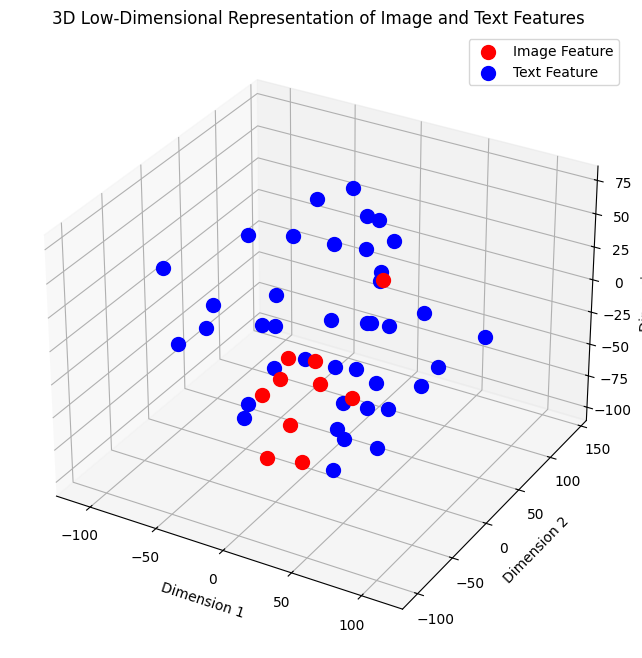

In [39]:
# 步骤 1: 准备数据（与2D版本相同）
# 将 image_features 和 text_features 转换为 NumPy 数组

# 1. 转换为numpy数组并降维
text_feats = []
for t in text_features:
    if isinstance(t, torch.Tensor):
        feat = t.squeeze(0).detach().cpu().numpy()
    else:
        feat = np.array(t).squeeze()
    text_feats.append(feat)

image_feats = []
for i in image_features:
    if isinstance(i, torch.Tensor):
        feat = i.squeeze(0).detach().cpu().numpy()
    else:
        feat = np.array(i).squeeze()
    image_feats.append(feat)

text_feats = np.array(text_feats)  # (25, 768)
image_feats = np.array(image_feats)  # (5, 2048)

# 方案2: 池化图像特征到768维

image_feats_aligned = np.zeros((len(image_features), 768))
for i, img_feat in enumerate(image_feats):
    img_feat_tensor = torch.tensor(img_feat).float().unsqueeze(0)  # [1, 2048]
    img_feat_pooled = F.adaptive_avg_pool1d(img_feat_tensor, 768).squeeze(0).numpy()  # [768]
    image_feats_aligned[i] = img_feat_pooled
text_feats_aligned = text_feats

# image_feat_tensor = torch.tensor(image_features).unsqueeze(0).cpu()  # [1, 2048]
# image_feat_pooled = F.adaptive_avg_pool1d(image_feat_tensor, 768).squeeze(0).numpy()  # [768]

# 合并所有特征为 [6, 768] 数组
all_features = np.vstack([image_feats_aligned, text_feats_aligned])  # [6, 768]

# 步骤 2: 应用 t-SNE 降维到 3D
tsne = TSNE(n_components=3, perplexity=5, random_state=42)  # 改为 n_components=3
low_dim_features = tsne.fit_transform(all_features)  # [6, 3]

# 步骤 3: 3D 可视化
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')  # 创建3D轴

# 图像点（索引 0-9）
for i in range(10):
    ax.scatter(low_dim_features[i, 0], low_dim_features[i, 1], low_dim_features[i, 2], 
            color='red', label='Image Feature' if i == 0 else "", s=100)

# 文本点（索引 10-49）
for i in range(10, 50):
    ax.scatter(low_dim_features[i, 0], low_dim_features[i, 1], low_dim_features[i, 2], 
               color='blue', label='Text Feature' if i == 10 else "", s=100)

ax.set_title('3D Low-Dimensional Representation of Image and Text Features')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
ax.legend()
ax.grid(True)

# 显示图表（在笔记本中会自动渲染）
plt.show()

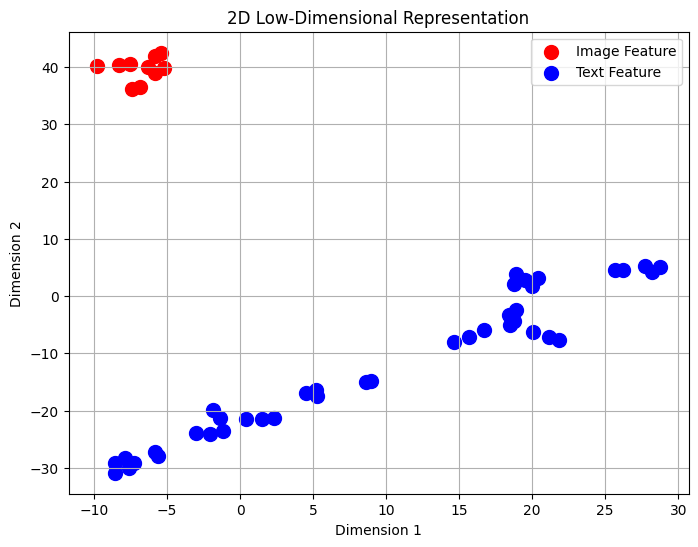

In [40]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
low_dim_features = tsne.fit_transform(all_features)  # [6, 2]

plt.figure(figsize=(8, 6))
for i in range(10):
    plt.scatter(low_dim_features[i, 0], low_dim_features[i, 1], color='red', label='Image Feature' if i == 0 else "", s=100)

for i in range(10, 50):
    plt.scatter(low_dim_features[i, 0], low_dim_features[i, 1],
                color='blue', label='Text Feature' if i == 10 else "", s=100)

plt.title('2D Low-Dimensional Representation')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
image_shareds = []
text_shareds = []
image_privates = []
text_privates = []
for i in range(10):
    for j in range(5):
        features = visualizer.encode_to_shared_private(image_features[i], text_features[i*5 + j])
        image_shareds.append(features['image_shared']) if j % 5 == 0 else None
        text_shareds.append(features['text_shared'])
        image_privates.append(features['image_private']) if j % 5 == 0 else None
        text_privates.append(features['text_private'])

In [60]:
len(image_shareds)

10

(50, 256) (10, 256)


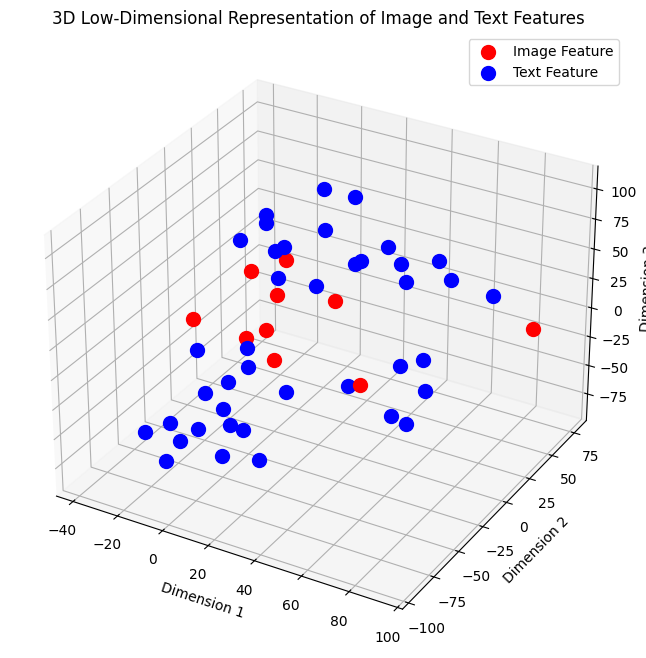

In [61]:
# 步骤 1: 准备数据（与2D版本相同）
# 将 image_features 和 text_features 转换为 NumPy 数组

# 1. 转换为numpy数组并降维
text_feats = []
for t in text_shareds:
    if isinstance(t, torch.Tensor):
        feat = t.squeeze(0).detach().cpu().numpy()
    else:
        feat = np.array(t).squeeze()
    text_feats.append(feat)

image_feats = []
for i in image_shareds:
    if isinstance(i, torch.Tensor):
        feat = i.squeeze(0).detach().cpu().numpy()
    else:
        feat = np.array(i).squeeze()
    image_feats.append(feat)

text_feats = np.array(text_feats)  # (25, 768)
image_feats = np.array(image_feats)  # (5, 2048)

print(text_feats.shape, image_feats.shape)

# # 方案2: 池化图像特征到768维

# image_feats_aligned = np.zeros((len(image_shareds), 768))
# for i, img_feat in enumerate(image_feats):
#     img_feat_tensor = torch.tensor(img_feat).float().unsqueeze(0)  # [1, 2048]
#     img_feat_pooled = F.adaptive_avg_pool1d(img_feat_tensor, 768).squeeze(0).numpy()  # [768]
#     image_feats_aligned[i] = img_feat_pooled
# text_feats_aligned = text_feats

# image_feat_tensor = torch.tensor(image_features).unsqueeze(0).cpu()  # [1, 2048]
# image_feat_pooled = F.adaptive_avg_pool1d(image_feat_tensor, 768).squeeze(0).numpy()  # [768]

# 合并所有特征为 [6, 768] 数组
all_features = np.vstack([image_feats, text_feats])  # [6, 768]

# 步骤 2: 应用 t-SNE 降维到 3D
tsne = TSNE(n_components=3, perplexity=5, random_state=42)  # 改为 n_components=3
low_dim_features = tsne.fit_transform(all_features)  # [6, 3]

# 步骤 3: 3D 可视化
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')  # 创建3D轴

# 图像点（索引 0-9）
for i in range(10):
    ax.scatter(low_dim_features[i, 0], low_dim_features[i, 1], low_dim_features[i, 2], 
            color='red', label='Image Feature' if i == 0 else "", s=100)

# 文本点（索引 10-49）
for i in range(10, 50):
    ax.scatter(low_dim_features[i, 0], low_dim_features[i, 1], low_dim_features[i, 2], 
               color='blue', label='Text Feature' if i == 10 else "", s=100)

ax.set_title('3D Low-Dimensional Representation of Image and Text Features')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
ax.legend()
ax.grid(True)

# 显示图表（在笔记本中会自动渲染）
plt.show()

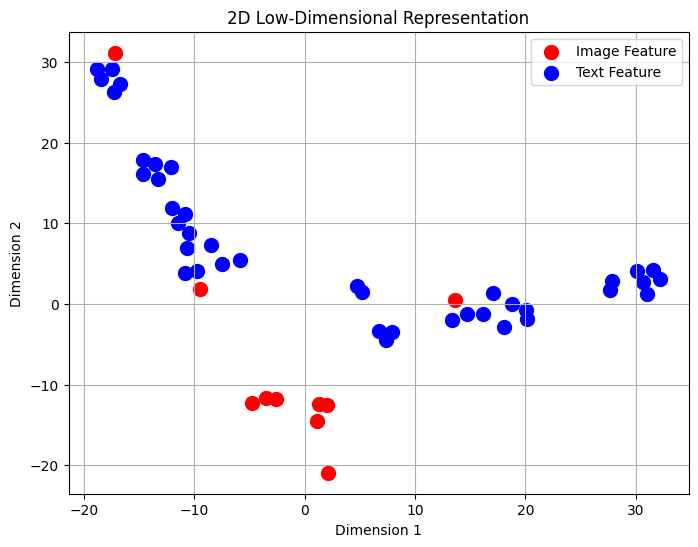

In [62]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
low_dim_features = tsne.fit_transform(all_features)  # [6, 2]

plt.figure(figsize=(8, 6))
for i in range(10):
    plt.scatter(low_dim_features[i, 0], low_dim_features[i, 1], color='red', label='Image Feature' if i == 0 else "", s=100)

for i in range(10, 50):
    plt.scatter(low_dim_features[i, 0], low_dim_features[i, 1],
                color='blue', label='Text Feature' if i == 10 else "", s=100)

plt.title('2D Low-Dimensional Representation')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True)
plt.show()